In [1]:
import tof

source = tof.Source(facility='ess', neutrons=1_000_000)
source.data

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:1000000, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [2787.35, 940.31, ..., 3216.82, 787.971]
* id                          int64        <no unit>  (pulse, event)  [0, 1, ..., 999998, 999999]
* speed                     float64            [m/s]  (pulse, event)  [734.514, 3237.09, ..., 1318.25, 3227.12]
* wavelength                float64             [Å]  (pulse, event)  [5.38592, 1.2221, ..., 3.00096, 1.22587]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]

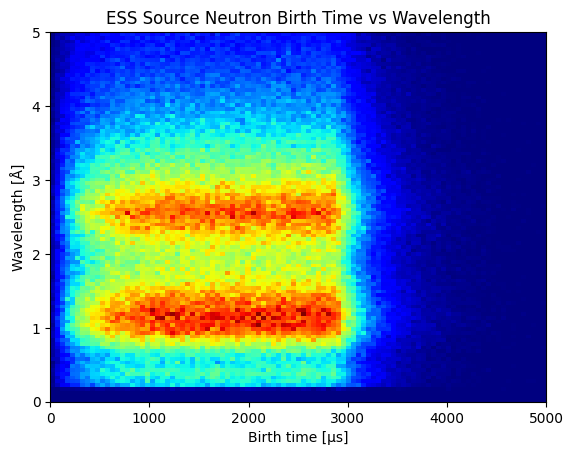

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


x = source.data.coords['birth_time'].values[0]
y = source.data.coords['wavelength'].values[0]
xedges = np.linspace(0, 5000, 100)
yedges = np.linspace(0, 5, 100)
H, xedges, yedges = np.histogram2d(x, y,bins=(xedges, yedges))

fig, ax = plt.subplots()
ax.pcolormesh(xedges, yedges, H.T, cmap='jet')
ax.set_xlabel(f'Birth time [{source.data.coords["birth_time"].unit}]')
ax.set_ylabel(f'Wavelength [{source.data.coords["wavelength"].unit}]')
ax.set_title('ESS Source Neutron Birth Time vs Wavelength')
plt.show(fig)

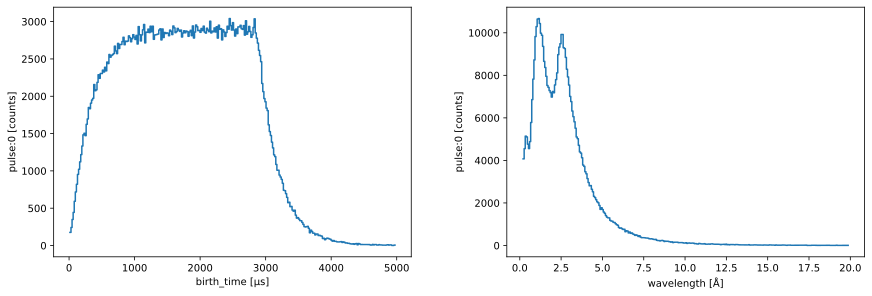

In [3]:
source = tof.Source(facility="ess", neutrons=500_000)
source.plot()
